C:\Users\Jakob\AppData\Local\Temp\ipykernel_19368\3950276510.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  k_pol[ik] = root


0 0.3491858545107318
1 0.11685344501009154
2 0.05652047941435456
3 0.031375404957207476
4 0.019230422793810042
5 0.012928474617206476
6 0.009512817867967094
7 0.006964218024656077
8 0.004866362884834885
9 0.0033154448142269644
10 0.0022254811265218777
11 0.0014800836516135618
12 0.0009785414456278119
13 0.000644077979901958
14 0.0004228629984242005
15 0.0002771372668499694
16 0.00018153326546155313
17 0.00011879475611742407
18 7.766608432113742e-05
19 5.0779455189164935e-05
20 3.319575427962462e-05
21 2.169796154749548e-05
22 1.4181585520134377e-05
23 9.268681551155566e-06
24 6.057502240253143e-06
25 3.9580581638887224e-06
26 2.585571000857101e-06
27 1.6886062237375654e-06
28 1.1026066264463452e-06
29 7.198704459199234e-07


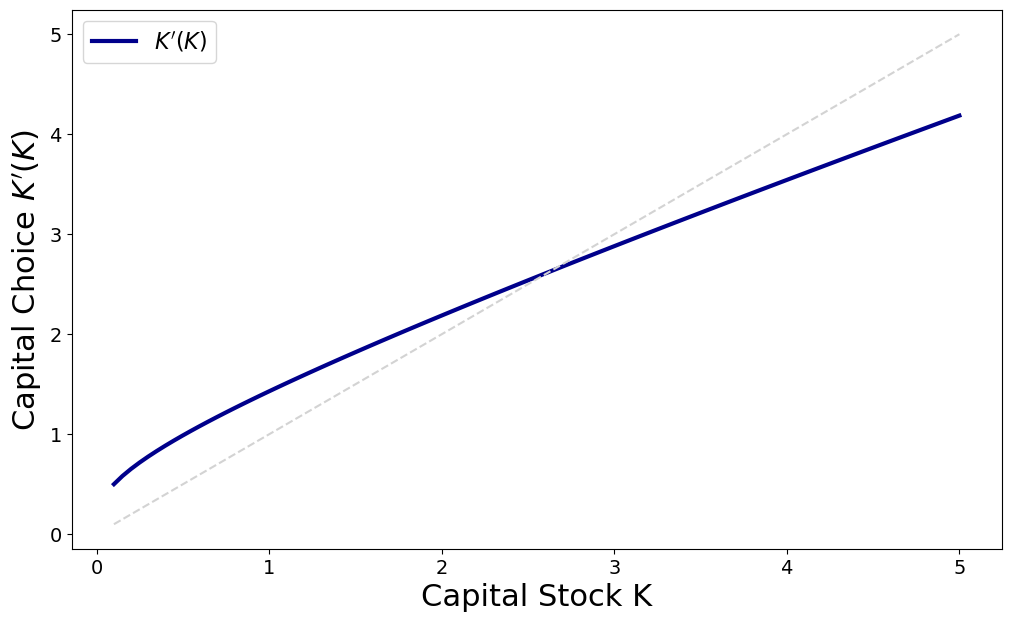

In [1]:
# Import the necessary libraries
import numpy as np
from scipy import interpolate, optimize
import matplotlib.pyplot as plt

# Optional
# plt.rc('text', usetex=True)
# plt.rc('font', family='serif')

# Economic parameters
betta = 0.95
alpha = 0.3
delta = 0.1
sigma = 0.25

# Grid parameters
k_min = 0.1
k_max = 5.0
nk = 100

# Technical parameters
maxiter = 10000
tol = 1e-6

# Initialization
kgrid = np.linspace(k_min, k_max, nk)
k_guess = np.zeros(nk)
k_guess[:] = (1-delta) * kgrid

# RHS of the Euler Equation for given k and a guess for k'
def sys_of_eqs(kp, k):
    kpp_interp = interpolate.interp1d(kgrid, k_guess, kind='linear', fill_value='extrapolate')
    kpp = kpp_interp(kp)

    c = k ** alpha + (1.0 - delta) * k - kp
    cp = kp ** alpha + (1.0 - delta) * kp - kpp

    ee_res = 1.0 - betta * (cp / c) ** (-sigma) * (alpha * kp ** (alpha - 1.0) + 1.0 - delta)

    return ee_res

# Main loop
k_pol = np.zeros(nk)

for iter0 in range(maxiter):

    for ik in range(nk):
        root = optimize.fsolve(sys_of_eqs, k_guess[ik], args=kgrid[ik])
        k_pol[ik] = root

    metric = np.amax(np.abs(k_pol - k_guess))
    print(iter0, metric)
    if (metric < tol):
        break

    k_guess[:] = k_pol

fig,ax=plt.subplots(figsize=(12,7))
ax.plot(kgrid,k_pol[:],color="darkblue",linewidth=3,label="$K'(K)$")
ax.plot(kgrid, kgrid, color='lightgrey', linestyle='dashed')

ax.set_ylabel("Capital Choice $K'(K)$", fontsize=22)
ax.set_xlabel("Capital Stock K", fontsize=22)
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=14)

plt.legend(fontsize= 16, loc='upper left')
plt.show()